# Análise e Validação Empírica dos Modelos Preditivos — StockSense (TCC 2026)

**Motor de Otimização Preditiva de Estoque · Mercados de Bairro**

Este notebook demonstra, de forma reprodutível, **por que** o motor escolhe um
modelo (Holt-Winters × Prophet) por produto e **prova** que a previsão funciona —
via gráficos de ajuste, análise de erro e resíduos. Os números aqui são idênticos
aos do serviço `/predict`, porque o notebook **reaproveita o código de produção**
(`app/services/...`) em vez de reimplementar as fórmulas.

## Passos de uma análise de dados com ML (roteiro deste notebook)

Seguimos o ciclo CRISP-DM adaptado a séries temporais:

1. **Entendimento do problema** — prever a demanda diária para dimensionar reposição.
2. **Coleta e entendimento dos dados** — histórico de vendas por produto (mín. 90 dias).
3. **Análise exploratória (EDA)** — série, decomposição, sazonalidade semanal.
4. **Pré-processamento** — índice diário contínuo, tratamento de zeros/fechamentos.
5. **Divisão temporal (walk-forward, nunca aleatória)** — 80% treino / 20% teste.
6. **Treinamento** — Holt-Winters e Prophet.
7. **Avaliação e comparação** — MAPE, RMSE, MAE + análise de resíduos.
8. **Interpretação / justificativa da decisão** — previsto × real, erro por horizonte.
9. **Aplicação de negócio** — estoque de segurança, ponto de reposição, dias até ruptura.
10. **Validação e limitações** — histórico curto, MAPE alto, promoções.
11. **Reprodutibilidade** — seed fixa, dados documentados, notebook versionado.


## 0. Configuração do ambiente

Coloca a raiz do `ml-service` no `sys.path` (o notebook mora em `analysis/`), importa o código de produção, fixa a semente e prepara as pastas de saída.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Raiz do ml-service = pasta-pai de analysis/ — permite `from app...`
RAIZ = Path.cwd().parent if Path.cwd().name == "analysis" else Path.cwd()
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

# Código de PRODUÇÃO (reaproveitado — não reimplementamos fórmulas)
from app.services import holt_winters_service as hw
from app.services import stock_service
from app.tests.generate_synthetic_data import gerar_dataset, PRODUTOS_META

# Utilitários de análise (reusam os helpers internos dos serviços)
import analysis_utils as au

SEED = 42
np.random.seed(SEED)

FIG_DIR = RAIZ / "analysis" / "figures"
RESULTS_DIR = RAIZ / "analysis" / "results"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "figure.dpi": 110, "font.size": 10})

PROPHET_OK = au.prophet_disponivel()
print("Prophet disponível neste ambiente:", PROPHET_OK)
if not PROPHET_OK:
    print("  -> Ambiente do Prophet indisponível (ver T-12 no tasks.md).")
    print("  -> O notebook segue apenas com Holt-Winters e sinaliza a limitação.")
else:
    from app.services import prophet_service as pr

def salvar(fig, nome):
    caminho = FIG_DIR / nome
    fig.savefig(caminho, bbox_inches="tight")
    print("figura salva:", caminho.relative_to(RAIZ))


Prophet disponível neste ambiente: False
  -> Ambiente do Prophet indisponível (ver T-12 no tasks.md).
  -> O notebook segue apenas com Holt-Winters e sinaliza a limitação.


## 1-2. Entendimento e coleta dos dados (sintético, reprodutível)

Usamos o gerador sintético do projeto (`gerar_dataset`, seed 42): 10 produtos, 365 dias, com tendência + sazonalidade semanal + ruído + fechamentos (domingos/feriados). Escolhemos dois perfis contrastantes para as análises visuais:
- **Estável** — *Arroz 5kg* (id 1, baixa variabilidade)
- **Volátil** — *Banana Prata kg* (id 5, alta variabilidade)

É no contraste entre eles que fica claro *por que* um modelo pode vencer o outro.

In [2]:
_, series = gerar_dataset(random_state=SEED)
nomes = {p["produto_id"]: p["nome"] for p in PRODUTOS_META}
meta = {p["produto_id"]: p for p in PRODUTOS_META}

ID_ESTAVEL, ID_VOLATIL = 1, 5

# Estatísticas descritivas por produto (base do "entendimento dos dados")
desc = []
for pid, s in series.items():
    ativos = s[s > 0]
    desc.append({
        "produto_id": pid, "nome": nomes[pid],
        "media_diaria": round(ativos.mean(), 2),
        "desvio(σ)": round(s.std(), 2),
        "CV": round(s.std() / s.mean(), 2) if s.mean() else np.nan,
        "%_zeros": round(float((s == 0).mean()) * 100, 1),
        "n_dias": len(s),
    })
tabela_desc = pd.DataFrame(desc).set_index("produto_id")
tabela_desc

,nome,media_diaria,desvio(σ),CV,%_zeros,n_dias
produto_id,,,,,,
1,Arroz 5kg,12.40,5.46,0.47,6.0,365
2,Feijão Carioca 1kg,8.27,3.86,0.51,8.5,365
3,Leite Integral 1L,21.52,11.62,0.58,7.7,365
4,Pão Francês,30.58,18.24,0.64,6.8,365
5,Banana Prata kg,16.53,10.57,0.68,6.3,365
6,Sal Refinado 1kg,5.21,2.29,0.48,7.7,365
7,Açúcar Cristal 1kg,7.27,3.21,0.48,7.4,365
8,Óleo de Soja 900ml,6.09,2.89,0.51,6.8,365
9,Frango Inteiro kg,10.44,5.45,0.56,7.4,365


## 3. Análise exploratória (EDA) — há sinal previsível?

**Gráfico 1 — série + decomposição** (tendência / sazonalidade semanal / resíduo). Se a sazonalidade semanal aparece nítida e o resíduo é pequeno frente ao sinal, há estrutura para os modelos capturarem — justifica usar Holt-Winters/Prophet em vez de uma média simples.

figura salva: analysis/figures/g1_decomposicao_produto1.png


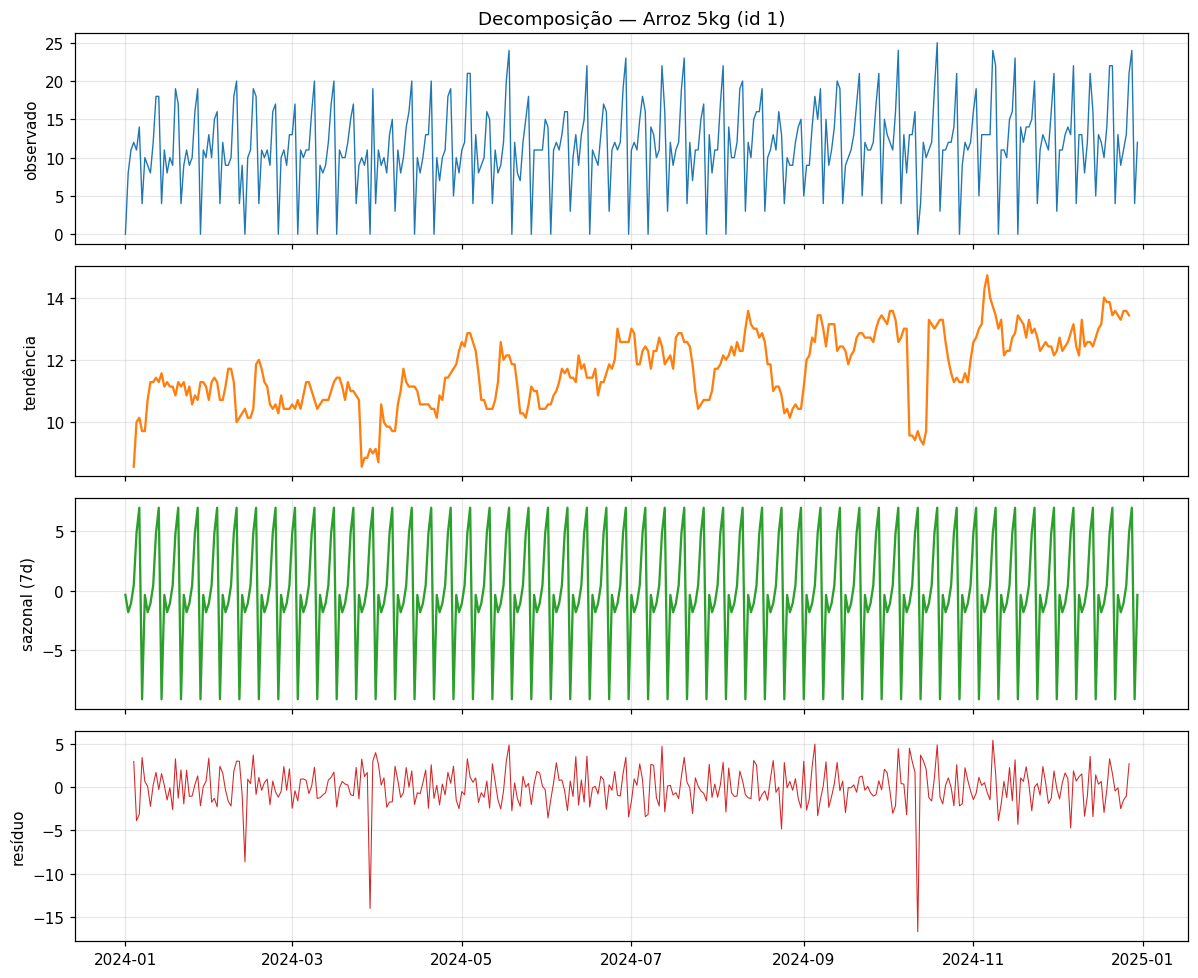

figura salva: analysis/figures/g1_decomposicao_produto5.png


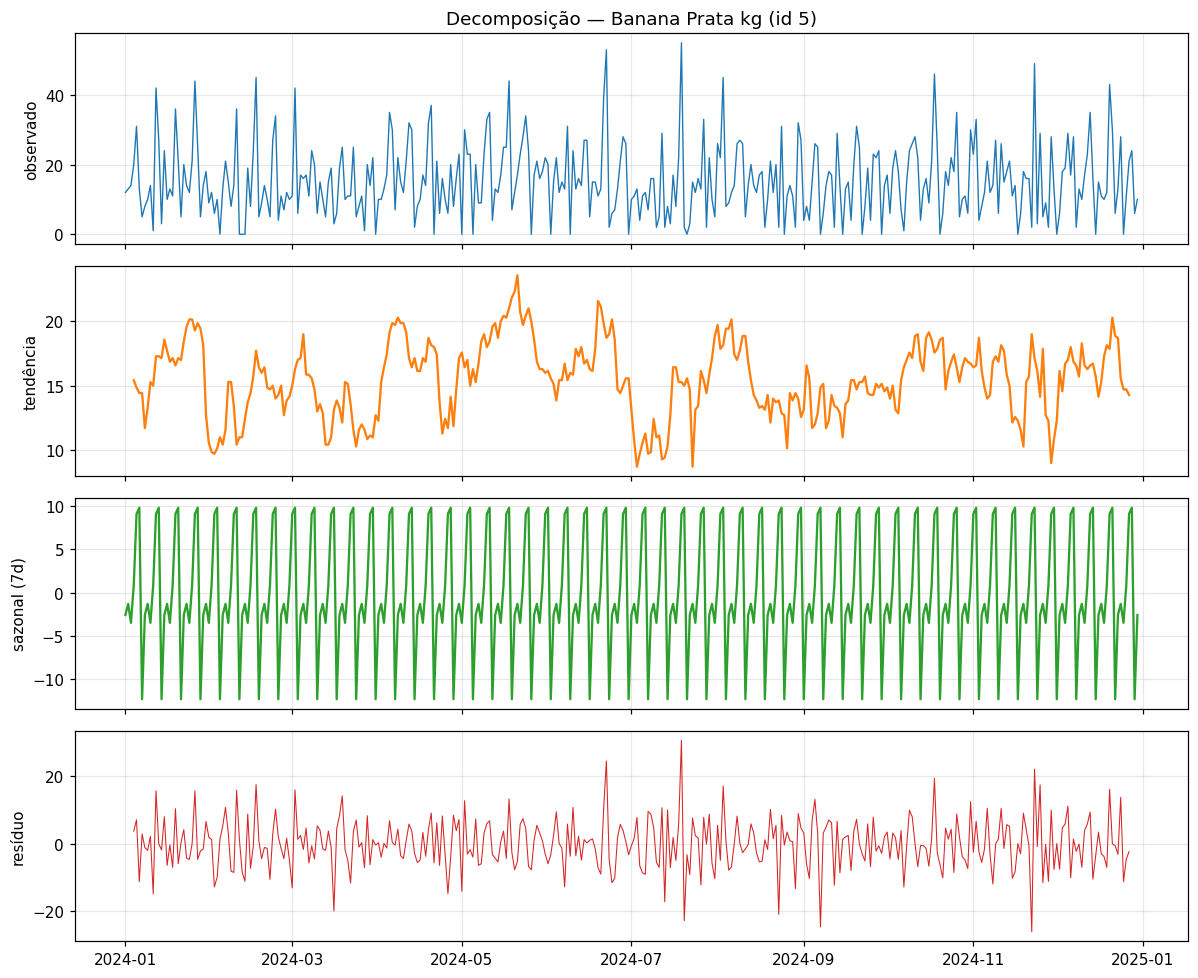

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose

def plot_decomposicao(pid):
    s = series[pid]
    dec = seasonal_decompose(s, model="additive", period=7)
    fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
    axes[0].plot(s.index, s.values, lw=0.9); axes[0].set_ylabel("observado")
    axes[1].plot(dec.trend.index, dec.trend.values, color="tab:orange"); axes[1].set_ylabel("tendência")
    axes[2].plot(dec.seasonal.index, dec.seasonal.values, color="tab:green"); axes[2].set_ylabel("sazonal (7d)")
    axes[3].plot(dec.resid.index, dec.resid.values, color="tab:red", lw=0.7); axes[3].set_ylabel("resíduo")
    axes[0].set_title(f"Decomposição — {nomes[pid]} (id {pid})")
    fig.tight_layout()
    salvar(fig, f"g1_decomposicao_produto{pid}.png")
    plt.show()

plot_decomposicao(ID_ESTAVEL)
plot_decomposicao(ID_VOLATIL)

## 4-5. Pré-processamento e divisão temporal (walk-forward)

A série já vem com índice diário contínuo (zeros preservados nos dias fechados). A avaliação usa **divisão por posição cronológica** — 80% treino / 20% teste — **nunca** `train_test_split` aleatório, que embaralharia o tempo e invalidaria a métrica (CLAUDE.md §6/§15). O mesmo split do motor em produção.

In [4]:
treino_ex, valid_ex = au.split_temporal(series[ID_ESTAVEL])
print(f"Produto {ID_ESTAVEL}: treino={len(treino_ex)} dias "
      f"({treino_ex.index.min().date()} → {treino_ex.index.max().date()}) | "
      f"teste={len(valid_ex)} dias "
      f"({valid_ex.index.min().date()} → {valid_ex.index.max().date()})")

Produto 1: treino=292 dias (2024-01-01 → 2024-10-18) | teste=73 dias (2024-10-19 → 2024-12-30)


## 6-7. Treinamento e avaliação dos dois modelos

Rodamos Holt-Winters e (quando disponível) Prophet na janela de validação, coletando previsões e métricas. As métricas saem de `_calcular_metricas` dos próprios serviços — idênticas às de produção.

In [5]:
def avaliar_todos(pid):
    res = {"holt_winters": au.avaliar_holt_winters(series[pid])}
    if PROPHET_OK:
        res["prophet"] = au.avaliar_prophet(series[pid])
    return res

resultados = {pid: avaliar_todos(pid) for pid in (ID_ESTAVEL, ID_VOLATIL)}

for pid, res in resultados.items():
    print(f"\n=== {nomes[pid]} (id {pid}) ===")
    for modelo, r in res.items():
        m = r["metricas"]
        print(f"  {modelo:<13} MAPE={m.mape:6.2f}%  RMSE={m.rmse:6.2f}  MAE={m.mae:6.2f}")

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)



=== Arroz 5kg (id 1) ===
  holt_winters  MAPE= 12.49%  RMSE=  2.25  MAE=  1.76

=== Banana Prata kg (id 5) ===
  holt_winters  MAPE= 66.73%  RMSE=  8.07  MAE=  6.18


### Gráfico 2 — Previsto × Real na janela de teste

O gráfico mais persuasivo: mostra o ajuste **fora da amostra**. Quanto mais a linha prevista acompanha a real, melhor o modelo generaliza para o futuro.

figura salva: analysis/figures/g2_previsto_real_produto1.png


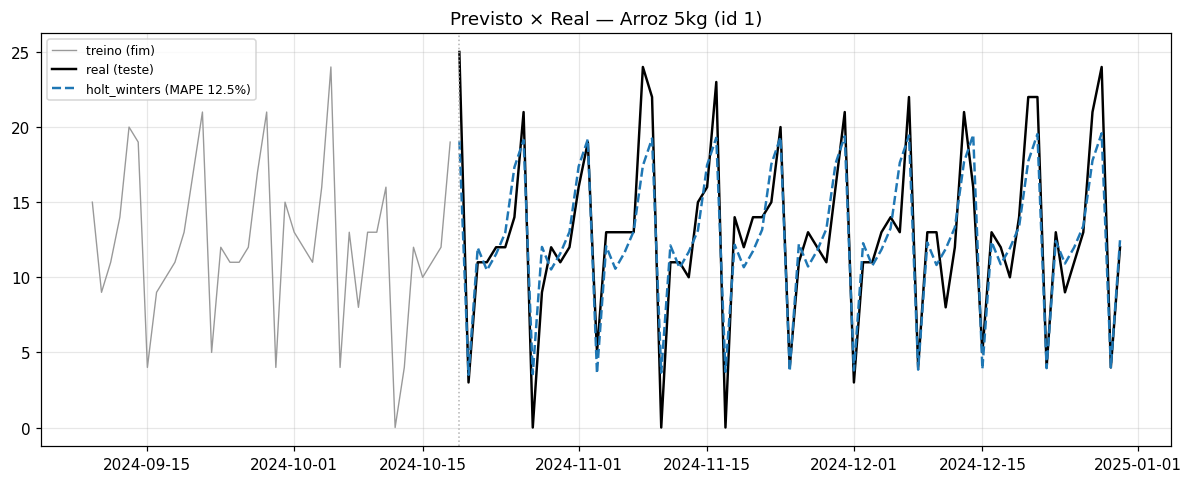

figura salva: analysis/figures/g2_previsto_real_produto5.png


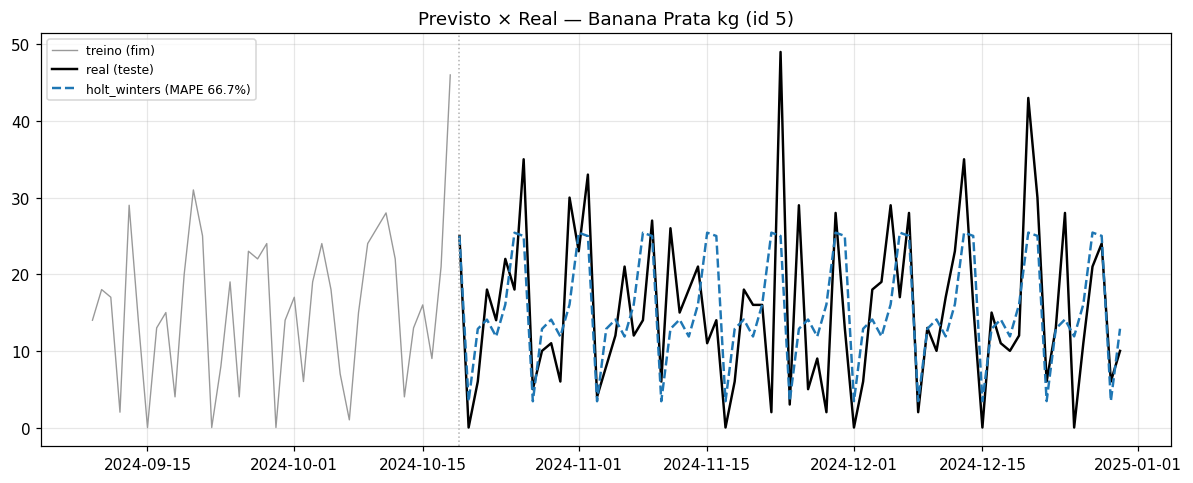

In [6]:
def plot_previsto_real(pid):
    res = resultados[pid]
    qualquer = next(iter(res.values()))
    treino, valid = qualquer["treino"], qualquer["validacao"]
    fig, ax = plt.subplots()
    ax.plot(treino.index[-40:], treino.values[-40:], color="0.6", lw=0.9, label="treino (fim)")
    ax.plot(valid.index, valid.values, color="black", lw=1.6, label="real (teste)")
    cores = {"holt_winters": "tab:blue", "prophet": "tab:red"}
    for modelo, r in res.items():
        m = r["metricas"]
        ax.plot(r["previsto"].index, r["previsto"].values, "--", color=cores[modelo],
                lw=1.6, label=f"{modelo} (MAPE {m.mape:.1f}%)")
    ax.axvline(valid.index[0], color="0.7", ls=":", lw=1)
    ax.set_title(f"Previsto × Real — {nomes[pid]} (id {pid})")
    ax.legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    salvar(fig, f"g2_previsto_real_produto{pid}.png")
    plt.show()

for pid in resultados:
    plot_previsto_real(pid)

### Gráfico 3 — Comparativo de erro (MAPE / RMSE / MAE)

Espelha a **Tela 10** do sistema: barras lado a lado por métrica. É a justificativa quantitativa da escolha do modelo (menor MAPE vence).

figura salva: analysis/figures/g3_barras_erro_produto1.png


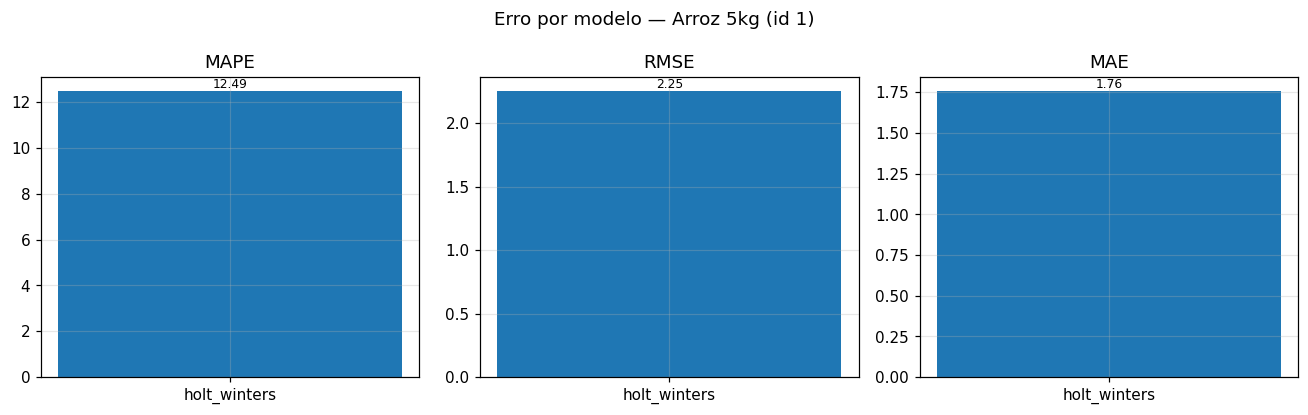

figura salva: analysis/figures/g3_barras_erro_produto5.png


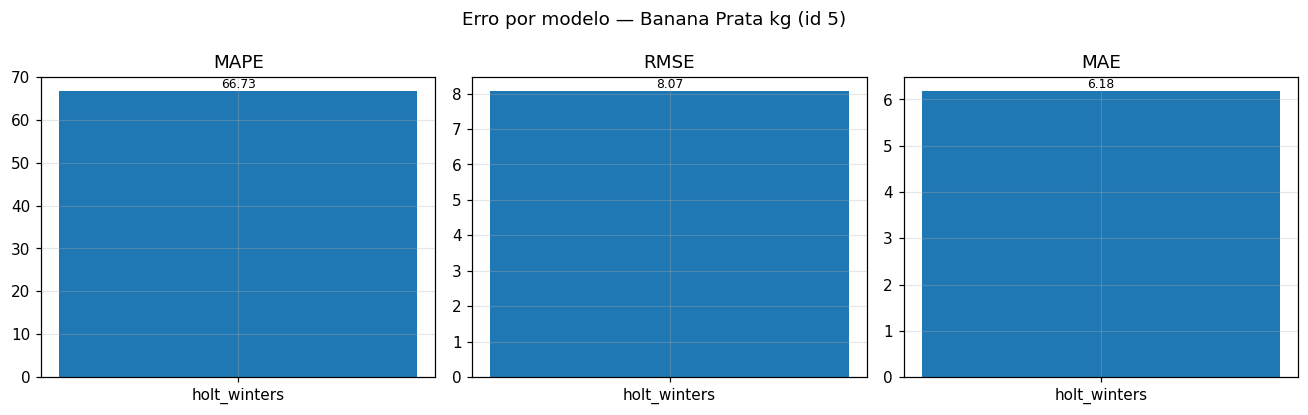

In [7]:
def plot_barras_erro(pid):
    res = resultados[pid]
    modelos = list(res.keys())
    metric_names = ["mape", "rmse", "mae"]
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
    for ax, met in zip(axes, metric_names):
        valores = [getattr(res[mo]["metricas"], met) for mo in modelos]
        cores = ["tab:blue", "tab:red"][:len(modelos)]
        ax.bar(modelos, valores, color=cores)
        ax.set_title(met.upper())
        for i, v in enumerate(valores):
            ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=8)
    fig.suptitle(f"Erro por modelo — {nomes[pid]} (id {pid})")
    fig.tight_layout()
    salvar(fig, f"g3_barras_erro_produto{pid}.png")
    plt.show()

for pid in resultados:
    plot_barras_erro(pid)

### Gráfico 4 — Erro por horizonte de previsão

Como o erro absoluto evolui conforme prevemos mais dias à frente dentro da janela de teste. Normalmente cresce com o horizonte — informa até quando confiar na previsão.

figura salva: analysis/figures/g4_erro_horizonte_produto1.png


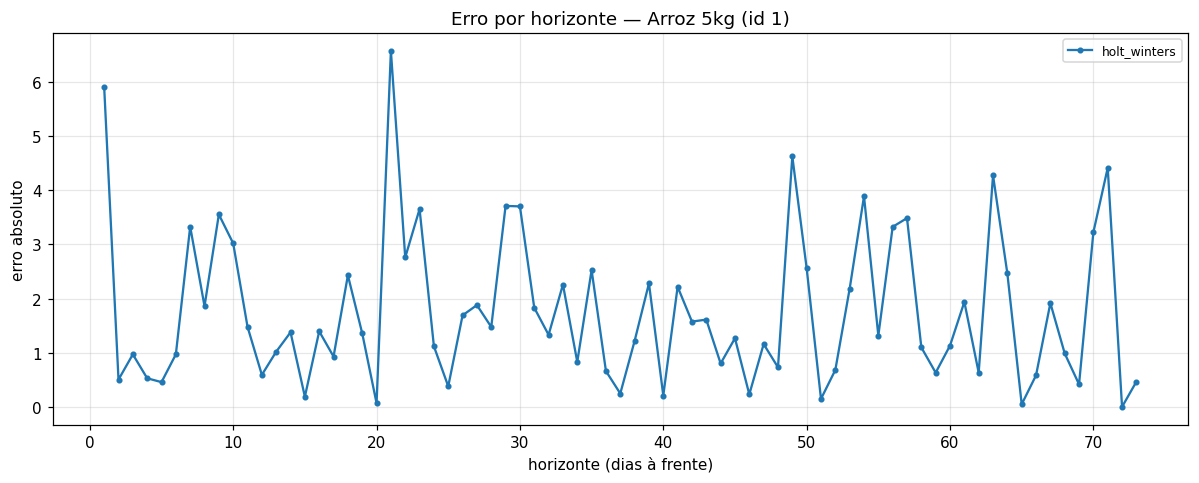

figura salva: analysis/figures/g4_erro_horizonte_produto5.png


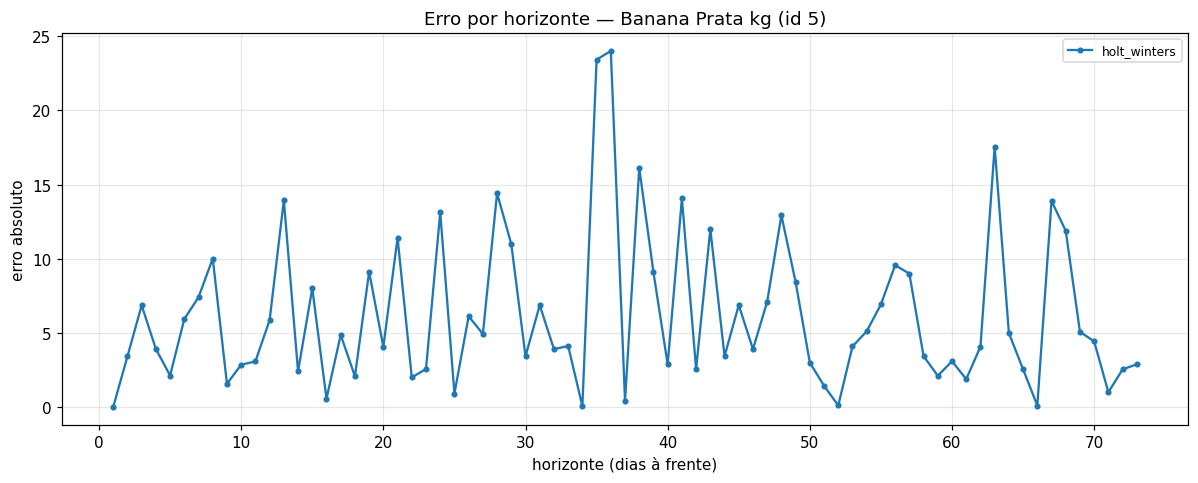

In [8]:
def plot_erro_horizonte(pid):
    res = resultados[pid]
    fig, ax = plt.subplots()
    cores = {"holt_winters": "tab:blue", "prophet": "tab:red"}
    for modelo, r in res.items():
        erro = np.abs(r["validacao"].values - r["previsto"].values)
        ax.plot(range(1, len(erro) + 1), erro, marker="o", ms=3, color=cores[modelo], label=modelo)
    ax.set_xlabel("horizonte (dias à frente)"); ax.set_ylabel("erro absoluto")
    ax.set_title(f"Erro por horizonte — {nomes[pid]} (id {pid})")
    ax.legend(fontsize=8)
    fig.tight_layout()
    salvar(fig, f"g4_erro_horizonte_produto{pid}.png")
    plt.show()

for pid in resultados:
    plot_erro_horizonte(pid)

### Gráfico 5 — Análise de resíduos

Resíduo = real − previsto. Um bom modelo deixa resíduos **centrados em zero, sem padrão e sem autocorrelação** (≈ ruído branco). Padrões no resíduo indicam sinal não capturado. Mostramos histograma + resíduo no tempo + ACF.

figura salva: analysis/figures/g5_residuos_produto1_holt_winters.png


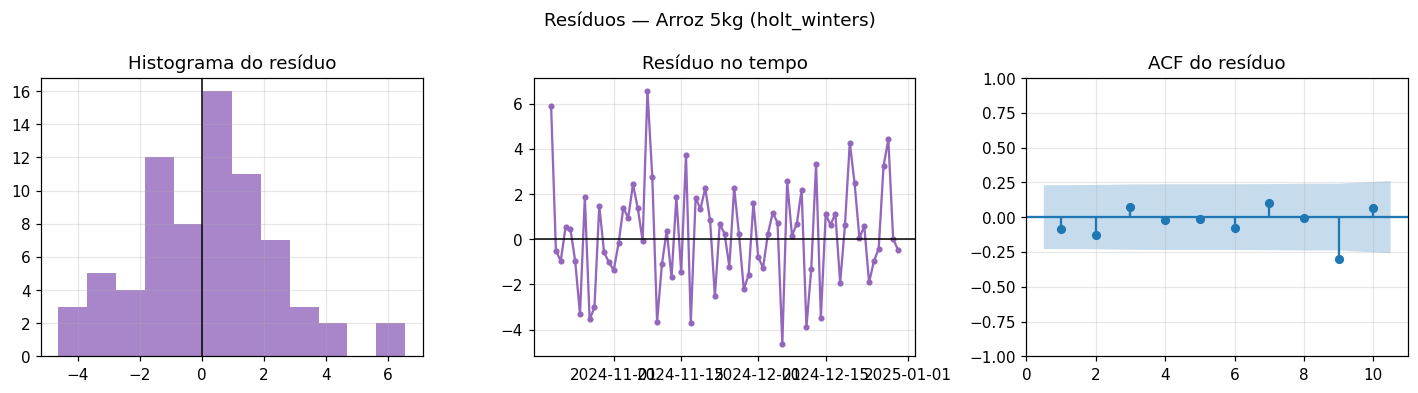

figura salva: analysis/figures/g5_residuos_produto5_holt_winters.png


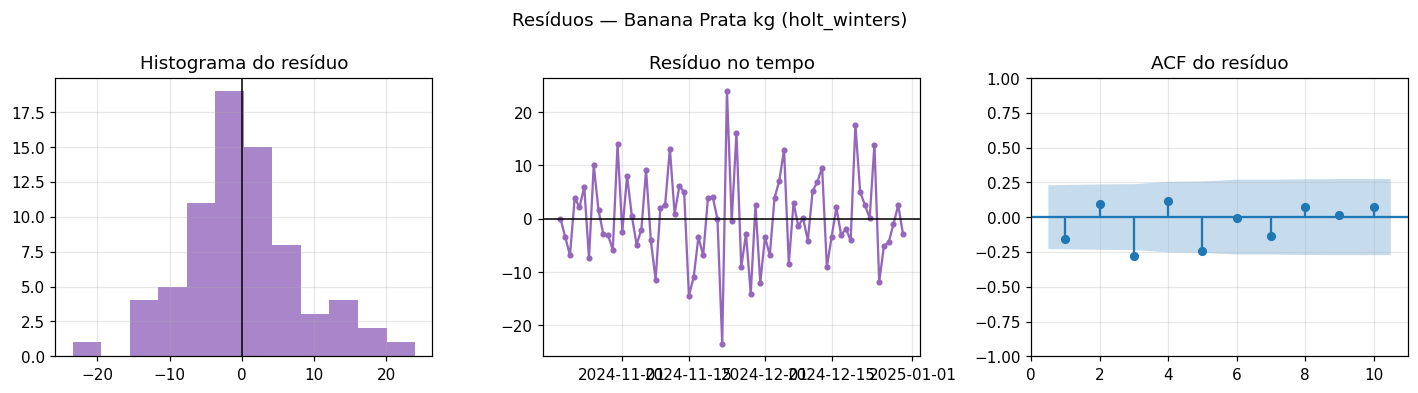

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

def plot_residuos(pid, modelo="holt_winters"):
    r = resultados[pid][modelo]
    resid = r["validacao"].values - r["previsto"].values
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
    axes[0].hist(resid, bins=12, color="tab:purple", alpha=0.8)
    axes[0].axvline(0, color="k", lw=1); axes[0].set_title("Histograma do resíduo")
    axes[1].plot(r["validacao"].index, resid, marker="o", ms=3, color="tab:purple")
    axes[1].axhline(0, color="k", lw=1); axes[1].set_title("Resíduo no tempo")
    n_lags = min(10, len(resid) // 2 - 1)
    if n_lags >= 1:
        plot_acf(resid, ax=axes[2], lags=n_lags, zero=False)
    axes[2].set_title("ACF do resíduo")
    fig.suptitle(f"Resíduos — {nomes[pid]} ({modelo})")
    fig.tight_layout()
    salvar(fig, f"g5_residuos_produto{pid}_{modelo}.png")
    plt.show()

for pid in resultados:
    plot_residuos(pid)

### Gráfico 6 — Backtesting rolling-origin (robustez)

Repetimos treino/teste em várias janelas móveis. Se o erro é consistente entre dobras, o desempenho não é fruto de uma única divisão sortuda.

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


figura salva: analysis/figures/g6_backtesting_produto1.png


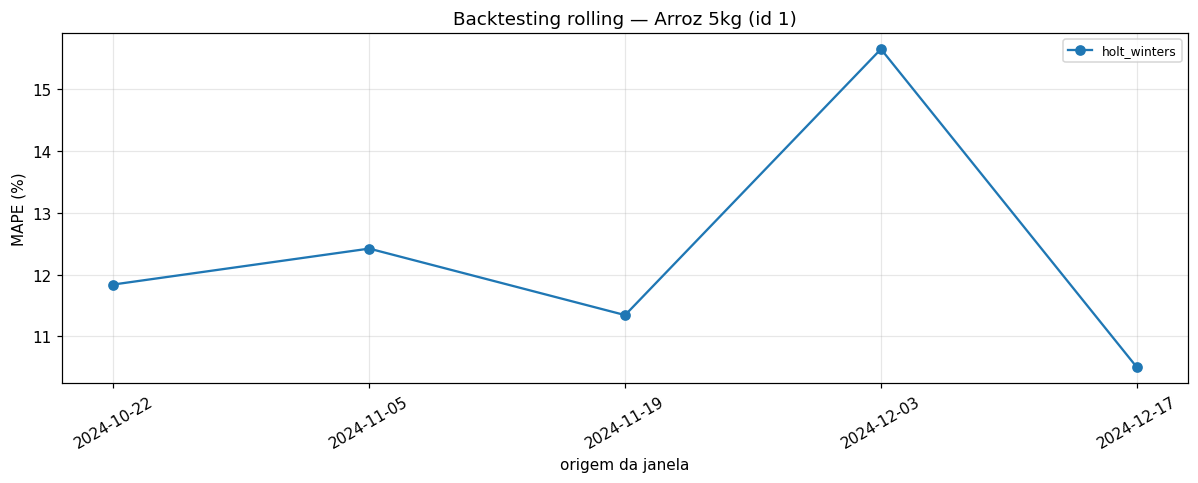

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


figura salva: analysis/figures/g6_backtesting_produto5.png


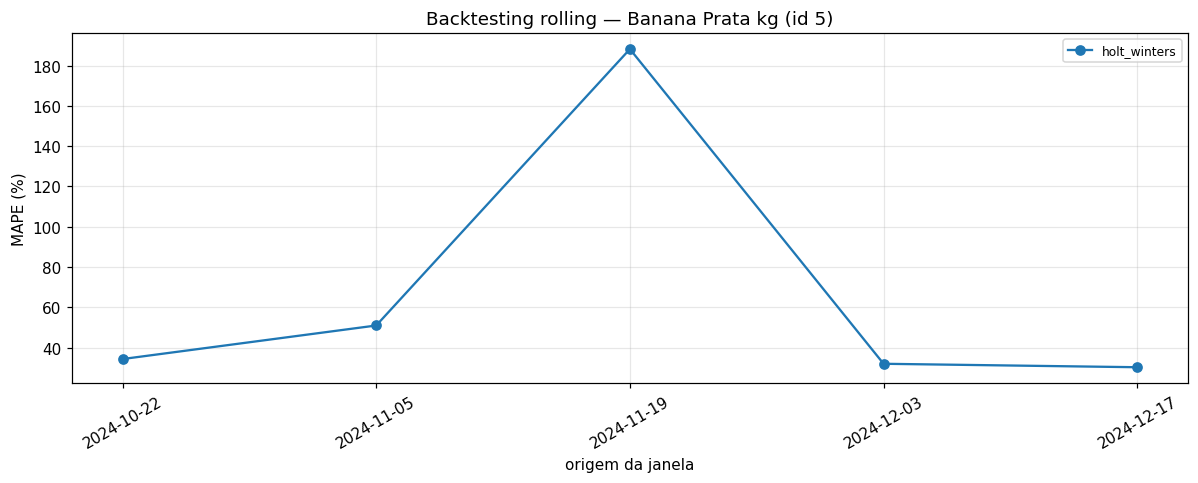

In [10]:
def plot_backtesting(pid):
    fig, ax = plt.subplots()
    bt_hw = au.backtesting_rolling(series[pid], au.prever_hw)
    ax.plot(bt_hw["origem"], bt_hw["mape"], marker="o", color="tab:blue", label="holt_winters")
    if PROPHET_OK:
        bt_pr = au.backtesting_rolling(series[pid], au.prever_prophet)
        ax.plot(bt_pr["origem"], bt_pr["mape"], marker="s", color="tab:red", label="prophet")
    ax.set_ylabel("MAPE (%)"); ax.set_xlabel("origem da janela")
    ax.set_title(f"Backtesting rolling — {nomes[pid]} (id {pid})")
    ax.tick_params(axis="x", rotation=30); ax.legend(fontsize=8)
    fig.tight_layout()
    salvar(fig, f"g6_backtesting_produto{pid}.png")
    plt.show()

for pid in resultados:
    plot_backtesting(pid)

## 9. Aplicação de negócio — da previsão à decisão de reposição

**Gráfico 7** liga a estatística à ação do lojista. Com a demanda média prevista (modelo vencedor) e o desvio da série, calculamos via `stock_service` (fórmula de Ballou): **estoque de segurança**, **ponto de reposição** e **dias até ruptura**. Simulamos a queda do estoque atual e marcamos quando ele cruza o ponto de reposição (momento de pedir).

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


figura salva: analysis/figures/g7_reposicao_produto1.png


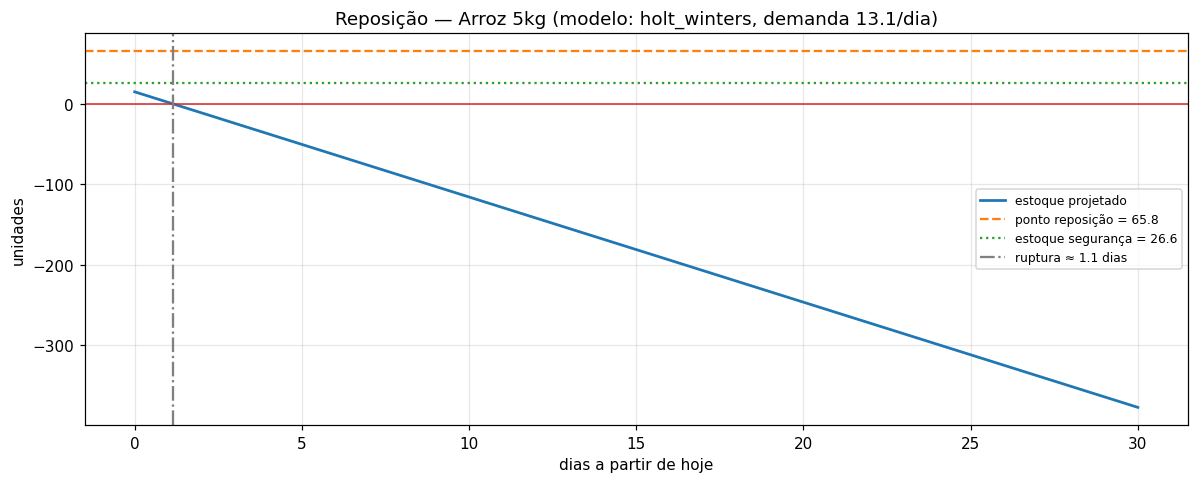

{'vencedor': 'holt_winters', 'demanda_media': 13.089383913466692, 'es': 26.56032299594364, 'pr': 65.82847473634372, 'estoque_atual': 15, 'dias': 1.1459668460459485}


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


figura salva: analysis/figures/g7_reposicao_produto5.png


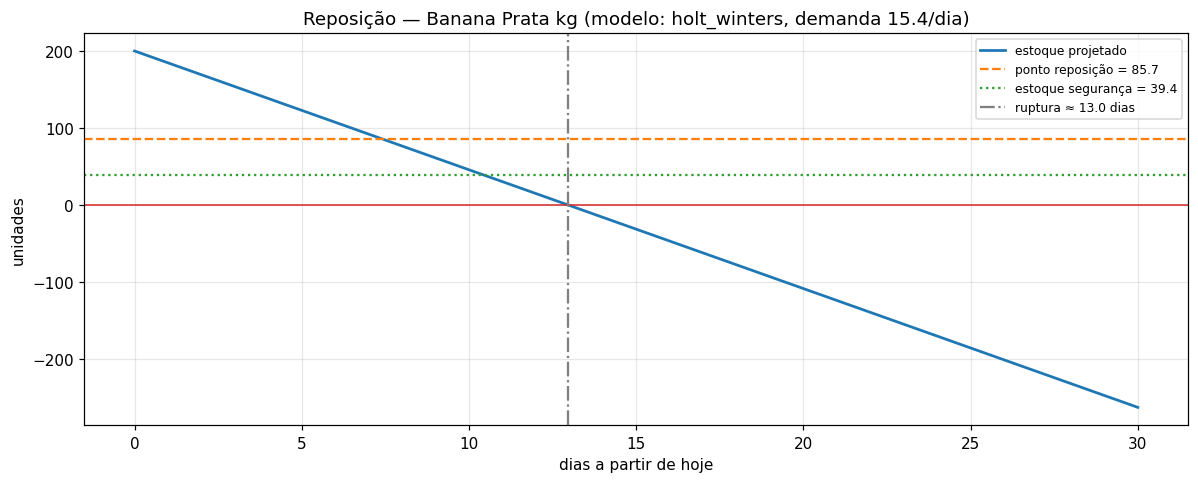

{'vencedor': 'holt_winters', 'demanda_media': 15.432937446453455, 'es': 39.39219173639926, 'pr': 85.69100407575962, 'estoque_atual': 200, 'dias': 12.959295707244685}


In [11]:
def kpis_estoque(pid, lead_time=3, variab_lt=1.0, nivel=0.95):
    s = series[pid]
    # Modelo vencedor pela mesma regra do motor (menor MAPE; empate -> HW)
    metr_hw, prev_hw = hw.treinar_e_avaliar(s)
    candidatos = {"holt_winters": (metr_hw, prev_hw)}
    if PROPHET_OK:
        metr_pr, prev_pr = pr.treinar_e_avaliar(s)
        candidatos["prophet"] = (metr_pr, prev_pr)
    vencedor = min(candidatos, key=lambda k: candidatos[k][0].mape)
    _, previsao = candidatos[vencedor]

    demanda_media = float(previsao.mean())
    desvio = float(s.std())
    z = stock_service.calcular_z_score(nivel)
    es = stock_service.calcular_estoque_seguranca(z, lead_time, desvio, demanda_media, variab_lt)
    pr_ = stock_service.calcular_ponto_reposicao(demanda_media, lead_time, es)
    estoque_atual = meta[pid]["estoque_atual"]
    dias = stock_service.calcular_dias_ate_ruptura(estoque_atual, demanda_media)
    return dict(vencedor=vencedor, demanda_media=demanda_media, es=es, pr=pr_,
                estoque_atual=estoque_atual, dias=dias)

def plot_kpis(pid):
    k = kpis_estoque(pid)
    dias_proj = np.arange(0, 31)
    estoque_proj = k["estoque_atual"] - k["demanda_media"] * dias_proj
    fig, ax = plt.subplots()
    ax.plot(dias_proj, estoque_proj, color="tab:blue", lw=1.8, label="estoque projetado")
    ax.axhline(k["pr"], color="tab:orange", ls="--", label=f"ponto reposição = {k['pr']:.1f}")
    ax.axhline(k["es"], color="tab:green", ls=":", label=f"estoque segurança = {k['es']:.1f}")
    ax.axhline(0, color="tab:red", lw=1)
    if k["dias"] is not None and k["dias"] <= 30:
        ax.axvline(k["dias"], color="0.5", ls="-.", label=f"ruptura ≈ {k['dias']:.1f} dias")
    ax.set_xlabel("dias a partir de hoje"); ax.set_ylabel("unidades")
    ax.set_title(f"Reposição — {nomes[pid]} (modelo: {k['vencedor']}, demanda {k['demanda_media']:.1f}/dia)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    salvar(fig, f"g7_reposicao_produto{pid}.png")
    plt.show()
    return k

for pid in resultados:
    print(plot_kpis(pid))

## 7-8. Comparativo geral (todos os produtos) → CSV de resultados

Rodamos os dois modelos em **todos os SKUs** via a função pública `treinar_e_avaliar` (produção) e consolidamos uma tabela por produto × modelo, com o vencedor e a margem de MAPE. Alimenta a discussão do TCC ('o modelo X venceu em Y% dos produtos').

In [12]:
linhas = []
for pid, s in series.items():
    registros = {}
    try:
        m_hw, _ = hw.treinar_e_avaliar(s)
        registros["holt_winters"] = m_hw
    except Exception as e:
        print(f"HW falhou p/ {pid}: {e}")
    if PROPHET_OK:
        try:
            m_pr, _ = pr.treinar_e_avaliar(s)
            registros["prophet"] = m_pr
        except Exception as e:
            print(f"Prophet falhou p/ {pid}: {e}")
    if not registros:
        continue
    vencedor = min(registros, key=lambda k: registros[k].mape)
    for modelo, m in registros.items():
        linhas.append({"produto_id": pid, "nome": nomes[pid], "modelo": modelo,
                       "mape": m.mape, "rmse": m.rmse, "mae": m.mae,
                       "vencedor": modelo == vencedor})

comparativo = pd.DataFrame(linhas)
destino_csv = RESULTS_DIR / "comparativo_modelos.csv"
comparativo.to_csv(destino_csv, index=False)
print("CSV salvo:", destino_csv.relative_to(RAIZ))

if PROPHET_OK:
    vencedores = comparativo[comparativo["vencedor"]]["modelo"].value_counts()
    print("\nVitórias por modelo (menor MAPE):")
    print(vencedores.to_string())
comparativo

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


CSV salvo: analysis/results/comparativo_modelos.csv


,produto_id,nome,modelo,mape,rmse,mae,vencedor
0,1,Arroz 5kg,holt_winters,12.4886,2.2521,1.7583,True
1,2,Feijão Carioca 1kg,holt_winters,13.2643,1.4155,1.1231,True
2,3,Leite Integral 1L,holt_winters,42.0490,9.1052,7.4062,True
3,4,Pão Francês,holt_winters,83.4253,16.2211,12.0806,True
4,5,Banana Prata kg,holt_winters,66.7259,8.0726,6.1822,True
5,6,Sal Refinado 1kg,holt_winters,9.6250,1.0852,0.5875,True
6,7,Açúcar Cristal 1kg,holt_winters,8.8945,1.7412,0.9415,True
7,8,Óleo de Soja 900ml,holt_winters,21.4335,2.1356,1.4210,True
8,9,Frango Inteiro kg,holt_winters,25.3948,3.7548,2.6510,True
9,10,Refrigerante 2L,holt_winters,28.3011,4.7084,3.3909,True


## Demonstração com dataset REAL (opcional)

Se você depositar a planilha real de vendas em `analysis/data/vendas_real.xlsx` (formato `5_vendas` do Guia de Importação: colunas `produto_id`, `data_hora`, `quantidade`), o bloco abaixo repete a avaliação e o gráfico previsto × real para o produto com mais histórico. Sem o arquivo, a seção é **pulada** com aviso — o notebook roda normalmente só com o sintético.

In [13]:
caminho_real = RAIZ / "analysis" / "data" / "vendas_real.xlsx"
if not caminho_real.exists():
    print(f"[pulado] Dataset real não encontrado em {caminho_real.relative_to(RAIZ)}.")
    print("Coloque o .xlsx nessa pasta para rodar esta seção.")
else:
    series_reais = au.carregar_series_reais(caminho_real)
    pid_real = max(series_reais, key=lambda k: int((series_reais[k] > 0).sum()))
    s_real = series_reais[pid_real]
    print(f"Produto real id {pid_real}: {len(s_real)} dias, "
          f"{int((s_real > 0).sum())} com venda, média {s_real[s_real>0].mean():.2f}/dia")

    r_hw = au.avaliar_holt_winters(s_real)
    print(f"Holt-Winters  MAPE={r_hw['metricas'].mape:.2f}%")
    if PROPHET_OK:
        r_pr = au.avaliar_prophet(s_real)
        print(f"Prophet       MAPE={r_pr['metricas'].mape:.2f}%")

    fig, ax = plt.subplots()
    ax.plot(r_hw["validacao"].index, r_hw["validacao"].values, color="black", lw=1.6, label="real")
    ax.plot(r_hw["previsto"].index, r_hw["previsto"].values, "--", color="tab:blue",
            label=f"holt_winters (MAPE {r_hw['metricas'].mape:.1f}%)")
    if PROPHET_OK:
        ax.plot(r_pr["previsto"].index, r_pr["previsto"].values, "--", color="tab:red",
                label=f"prophet (MAPE {r_pr['metricas'].mape:.1f}%)")
    ax.set_title(f"[REAL] Previsto × Real — produto {pid_real}")
    ax.legend(fontsize=8)
    fig.tight_layout()
    salvar(fig, f"g2_previsto_real_REAL_produto{pid_real}.png")
    plt.show()

[pulado] Dataset real não encontrado em analysis/data/vendas_real.xlsx.
Coloque o .xlsx nessa pasta para rodar esta seção.


## 10-11. Validação, limitações e reprodutibilidade

**Limitações (registrar honestamente no TCC):**
- **Histórico mínimo de 90 dias** — abaixo disso o motor recusa a previsão; a tela deve sinalizar.
- **MAPE > 50%** no vencedor → previsão de baixa confiança (o motor preenche o campo `aviso`).
- **Sazonalidade semanal** é o ciclo assumido (7 dias); ciclos anuais não cabem em 90-365 dias.
- **Promoções** — o regressor `is_promocional` do Prophet ainda não está ligado (T-10, opcional).
- **Dados sintéticos** validam a *metodologia*; a demonstração final ganha força com dados reais.

**Reprodutibilidade:**
- Semente fixa (`SEED=42`) em todo o pipeline; mesmo input → mesmos números.
- O notebook reusa o código de produção — as métricas coincidem com o `/predict`.
- Figuras salvas em `analysis/figures/` e a tabela em `analysis/results/comparativo_modelos.csv`.

> **Nota sobre o Prophet:** se `PROPHET_OK` estiver `False`, o ambiente do Prophet
> (CmdStan) precisa ser reinstalado — ver T-12 no `tasks.md`. O notebook roda só com
> Holt-Winters nesse caso, mas o comparativo (núcleo do TCC) exige os dois modelos.
